In [1]:

import numpy as np
from matplotlib import pyplot as plt
from dataclasses import dataclass
from echospec.utils.parameters import Parameters
from echospec.experiments.spectroscopy_vs_amplitude import AmplitudeSweepSpectroscopy, OptionsSpectroscopy2d
from echospec.utils.units import Units as u

from echospec.simulation.torry import find_fwhm_vec_vs_rabi
plt.style.use("paper.mplstyle")

Duplicate key in file 'paper.mplstyle', line 40 ('lines.linewidth     : 0.5')
Duplicate key in file 'paper.mplstyle', line 41 ('lines.markersize    : 4')
Bad value in file 'paper.mplstyle', line 17 ('font.size: 7,'): Key font.size: Could not convert '7,' to float
Bad value in file 'paper.mplstyle', line 18 ('axes.labelsize: 7,'): Key axes.labelsize: 7, is not a valid font size. Valid font sizes are xx-small, x-small, small, medium, large, x-large, xx-large, smaller, larger.
Bad value in file 'paper.mplstyle', line 19 ('xtick.labelsize: 6,'): Key xtick.labelsize: 6, is not a valid font size. Valid font sizes are xx-small, x-small, small, medium, large, x-large, xx-large, smaller, larger.
Bad value in file 'paper.mplstyle', line 20 ('ytick.labelsize: 6,'): Key ytick.labelsize: 6, is not a valid font size. Valid font sizes are xx-small, x-small, small, medium, large, x-large, xx-large, smaller, larger.
Bad value in file 'paper.mplstyle', line 21 ('legend.fontsize: 6,'): Key legend.fontsiz

1.99999980000002e-05


In [2]:
# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------
def run_spectroscopy(
    *,
    amplitudes,
    detunings,
    eco_pulse: bool,
    noise: float,
    num_time_points: int = 1000,
    cutoff: float = 0.05,
    pulse_length=50e-6

):
    options = OptionsSpectroscopy2d(
        plot=False,
        num_time_points=num_time_points,
        noise=noise,
        
    )

    params = Parameters()
    params.eco_pulse = eco_pulse
    params.cutoff = cutoff
    params.pulse_length = pulse_length

    experiment = AmplitudeSweepSpectroscopy(
        amplitudes=amplitudes,
        detunings=detunings,
        params=params,
        options=options,
    )

    return experiment.run()


In [3]:
import numpy as np

# ------------------------------------------------------------
# Sweep grids
# ------------------------------------------------------------
detunings = np.linspace(-0.2, 0.2, 51) * 2 * np.pi * u.MHz
amplitudes = np.linspace(0, 50, 51) * 2 * np.pi * u.MHz




# noise = 0.05
# echo_pulse = True
# # ------------------------------------------------------------
# # Runs
# # ------------------------------------------------------------
# results_clean = {
#     "c1": run_spectroscopy(
#         amplitudes=amplitudes,
#         detunings=detunings,
#         eco_pulse=echo_pulse,
#         noise=noise,
#         cutoff=3e-3,
#     ),
#     "c2": run_spectroscopy(
#         amplitudes=amplitudes,
#         detunings=detunings,
#         eco_pulse=echo_pulse,
#         noise=noise,
#         cutoff=1e-3
#     ),
#     "c3": run_spectroscopy(
#         amplitudes=amplitudes,
#         detunings=detunings,
#         eco_pulse=echo_pulse,
#         noise=noise,
#         cutoff=3e-4
#     ),
#     "c4": run_spectroscopy(
#         amplitudes=amplitudes,
#         detunings=detunings,
#         eco_pulse=echo_pulse,
#         noise=noise,
#         cutoff=1e-4
#     ),
# }

In [4]:
# fig, axes = plt.subplots(2, 2, figsize=(3.5, 3))
# axes = axes.flatten()

# for idx, (key, result) in enumerate(results_clean.items()):
#     ax = axes[idx]
#     x = result.amplitudes
#     y = result.detunings
#     z = result.populations
#     # # Extract the spectroscopy data (assuming the magnitude or real part)
#     # data = result.states
    
#     # # Create pcolormesh
#     mesh = ax.pcolormesh(
#         detunings / (2 * np.pi * u.MHz), 
#         amplitudes / (2 * np.pi * u.MHz), 
#         z,
#         shading='auto',
#         cmap='viridis',
#         vmin=0,
#         vmax=0.5
#     )
    
#     # ax.set_xlabel('Detuning (MHz)')
#     # ax.set_ylabel('Amplitude (MHz)')
#     # ax.set_title(f'{key}')
#     # plt.colorbar(mesh, ax=ax)

# plt.tight_layout()
# plt.show()

In [5]:


noise = 0.00
cutoff = 6e-4
echo_pulse = True
# ------------------------------------------------------------
# Runs
# ------------------------------------------------------------
def short_cut(pulse_length):
    return run_spectroscopy(
        amplitudes=amplitudes,
        detunings=detunings,
        eco_pulse=echo_pulse,
        noise=noise,
        cutoff=cutoff,
        pulse_length=pulse_length
    )
    
lengths = [2e-6, 5e-6, 10e-6, 20e-6, 30e-6, 40e-6, 50e-6, 100e-6, 200e-6]

results_clean = {
    "c1": short_cut(pulse_length=lengths[0]),
    "c2": short_cut(pulse_length=lengths[1]),
    "c3": short_cut(pulse_length=lengths[2]),
    "c4": short_cut(pulse_length=lengths[3]),
    "c5": short_cut(pulse_length=lengths[4]),
    "c6": short_cut(pulse_length=lengths[5]),
    "c7": short_cut(pulse_length=lengths[6]),
    "c8": short_cut(pulse_length=lengths[7]),
    "c9": short_cut(pulse_length=lengths[8]),
}

Amplitude sweep:   0%|          | 0/51 [00:00<?, ?Ω/s]

Amplitude sweep:   0%|          | 0/51 [00:00<?, ?Ω/s]

Amplitude sweep:   0%|          | 0/51 [00:00<?, ?Ω/s]

Amplitude sweep:   0%|          | 0/51 [00:00<?, ?Ω/s]

Amplitude sweep:   0%|          | 0/51 [00:00<?, ?Ω/s]

Amplitude sweep:   0%|          | 0/51 [00:00<?, ?Ω/s]

Amplitude sweep:   0%|          | 0/51 [00:00<?, ?Ω/s]

Amplitude sweep:   0%|          | 0/51 [00:00<?, ?Ω/s]

Amplitude sweep:   0%|          | 0/51 [00:00<?, ?Ω/s]

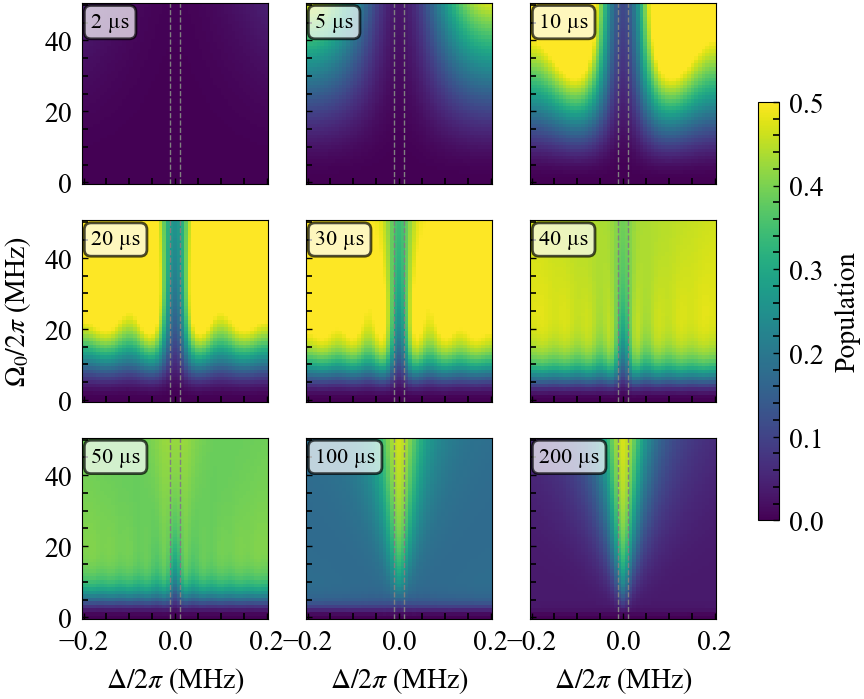

In [6]:
lengths = [2e-6, 5e-6, 10e-6, 20e-6, 30e-6, 40e-6, 50e-6, 100e-6, 200e-6]

fig, axes = plt.subplots(3, 3, figsize=(4.5, 4), sharex=True, sharey=True)
axes = axes.flatten()

params = Parameters()
T2_limit = params.T2_limit

for idx, (key, result) in enumerate(results_clean.items()):
    ax = axes[idx]
    x = result.amplitudes
    y = result.detunings
    z = result.populations
    # # Extract the spectroscopy data (assuming the magnitude or real part)
    # data = result.states
    
    # # Create pcolormesh
    mesh = ax.pcolormesh(
        detunings / (2 * np.pi * u.MHz), 
        amplitudes / (2 * np.pi * u.MHz), 
        z,
        shading='auto',
        cmap='viridis',
        vmin=0,
        vmax=0.5
    )
    
    ax.axvline(T2_limit / 2/1e6, color='gray', linestyle='--', label='T2 limit')
    ax.axvline(-T2_limit / 2/1e6, color='gray', linestyle='--', label='T2 limit')

    # ax.set_xlabel('Detuning (MHz)')
    # ax.set_ylabel('Amplitude (MHz)')
    
    # Add text box with cutoff value
    cutoff_value = list(results_clean.keys())[idx]
    cutoff_map = {
        "c1": lengths[0], "c2": lengths[1], "c3": lengths[2],
        "c4": lengths[3], "c5": lengths[4], "c6": lengths[5],
        "c7": lengths[6], "c8": lengths[7], "c9": lengths[8]
    }
    ax.text(0.05, 0.95, f'{(float(cutoff_map[cutoff_value])*1e6):.0f} µs', 
            transform=ax.transAxes, fontsize=8, 
            
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    # ax.set_title(f'{key}')
    # plt.colorbar(mesh, ax=ax)
    # Only set xlabel for bottom row
    if idx >= 6:
        ax.set_xlabel(r'$\Delta/2\pi$ (MHz)')
        
    # Only set ylabel for middle left subplot (index 3)
    if idx == 3:
        ax.set_ylabel(r'$\Omega_0/2\pi$ (MHz)')
        
        cbar = fig.colorbar(mesh, ax=axes, orientation='vertical', fraction=0.03, pad=0.06)
        cbar.set_label('Population')

# plt.tight_layout()
plt.savefig('spectroscopy_length_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:


noise = 0.05
pulse_length = 30e-6
# ------------------------------------------------------------
# Runs
# ------------------------------------------------------------
results_2 = {
    "square": run_spectroscopy(
        amplitudes=amplitudes/100,
        detunings=detunings,
        eco_pulse=False,
        noise=noise,
        cutoff=0.999,
        pulse_length=pulse_length
    ),
    "lorentzian": run_spectroscopy(
        amplitudes=amplitudes,
        detunings=detunings,
        eco_pulse=False,
        noise=noise,
        cutoff=0.0008,
        pulse_length=pulse_length
    ),
    "echo": run_spectroscopy(
        amplitudes=amplitudes,
        detunings=detunings,
        eco_pulse=True,
        noise=noise,
        cutoff=0.0008,
        pulse_length=pulse_length
    ),
    
}



Amplitude sweep:   0%|          | 0/51 [00:00<?, ?Ω/s]

Amplitude sweep:   0%|          | 0/51 [00:00<?, ?Ω/s]

Amplitude sweep:   0%|          | 0/51 [00:00<?, ?Ω/s]

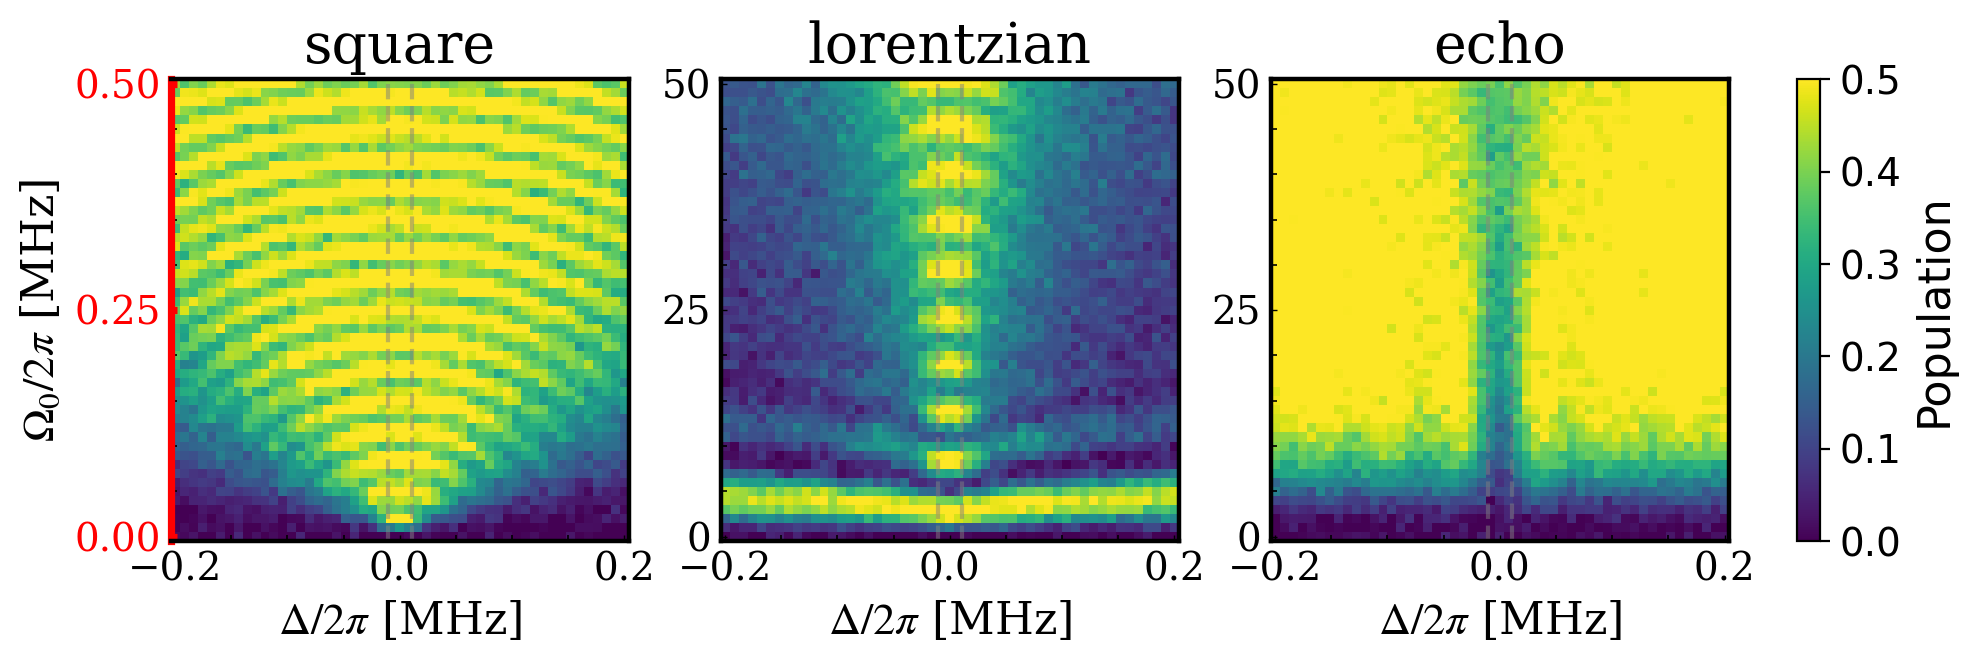

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharex=True, sharey=False)

params = Parameters()
plt.rcParams.update(plt.rcParamsDefault)
T2_limit = params.T2_limit

z_echo = results_2["echo"].populations
z_square = results_2["square"].populations

for idx, (key, result) in enumerate(results_2.items()):
    ax = axes[idx]
    z = result.populations
    
    factor = 100 if key == "square" else 1
    
    mesh = ax.pcolormesh(
        detunings / (2 * np.pi * u.MHz), 
        amplitudes / (2 * np.pi * u.MHz)/factor, 
        z,
        shading='auto',
        cmap='viridis',
        vmin=0,
        vmax=0.5
    )
    
    ax.axvline(T2_limit / 2/1e6, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(-T2_limit / 2/1e6, color='gray', linestyle='--', alpha=0.5)
    
    ax.set_xlabel(r'$\Delta/2\pi$ [MHz]')
    if idx == 0:
        ax.set_ylabel(r'$\Omega_0/2\pi$ [MHz]')
    
    ax.set_title(key, fontsize=26)
    
    if idx == 2:
        cbar = plt.colorbar(mesh, ax=axes, label='Population', fraction=0.046, pad=0.04)
        

    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xlabel(r'$\Delta/2\pi$ [MHz]', fontsize=16)
    if idx == 0:
        ax.set_ylabel(r'$\Omega_0/2\pi$ [MHz]', fontsize=16)
    ax.set_title(key, fontsize=20)

    if idx == 2:
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label('Population', fontsize=16)


        for ax in axes:
            for spine in ax.spines.values():
                spine.set_linewidth(1.6)
                
        axes[0].tick_params(axis='y', colors='red', width=2.6)
        axes[0].spines['left'].set_color('red')
        # axes[0].yaxis.label.set_color('red')
        # plt.tight_layout()
        
        
        axes[0].set_yticks([0, 0.25, 0.5])
        axes[1].set_yticks([0, 25, 50])
        axes[2].set_yticks([0, 25, 50])

        axes[0].spines['left'].set_linewidth(2.6)
        # axes[0].yaxis.label.set_color('red')
        
        
plt.savefig('spectroscopy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()